## Standard MNIST Neural Network with PyTorch

In [34]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [35]:
# Load data

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [36]:
# Define the model

class SimpleNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc2 = nn.Linear(400, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten 28x28 -> 784
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [37]:
# Set up training

model = SimpleNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epochs = 10

In [38]:
# Training Loop

for epoch in range (epochs):
    model.train()
    total_loss = 0
    correct = 0


    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    accuracy = correct / len(train_loader.dataset)
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.3f}, Accuracy: {accuracy:.2%}")

Epoch 1/10 - Loss: 0.561, Accuracy: 86.03%
Epoch 2/10 - Loss: 0.288, Accuracy: 91.72%
Epoch 3/10 - Loss: 0.238, Accuracy: 93.26%
Epoch 4/10 - Loss: 0.205, Accuracy: 94.20%
Epoch 5/10 - Loss: 0.181, Accuracy: 94.92%
Epoch 6/10 - Loss: 0.162, Accuracy: 95.47%
Epoch 7/10 - Loss: 0.146, Accuracy: 95.93%
Epoch 8/10 - Loss: 0.133, Accuracy: 96.29%
Epoch 9/10 - Loss: 0.122, Accuracy: 96.61%
Epoch 10/10 - Loss: 0.113, Accuracy: 96.89%


In [39]:
model.eval()
test_correct = 0

with torch.no_grad():

    for images, labels in test_loader:
        outputs = model(images)
        correct = (outputs.argmax(1) == labels).sum().item()

        test_correct += correct

test_accuracy = test_correct / len(test_loader.dataset)

print(f"Test Accuracy: {test_accuracy:.2%}")


Test Accuracy: 96.60%


Epoch 1/10 — Train Loss: 0.561, Train Acc: 85.91% | Test Loss: 0.307, Test Acc: 91.37%
Epoch 2/10 — Train Loss: 0.289, Train Acc: 91.81% | Test Loss: 0.250, Test Acc: 92.95%
Epoch 3/10 — Train Loss: 0.240, Train Acc: 93.25% | Test Loss: 0.214, Test Acc: 93.89%
Epoch 4/10 — Train Loss: 0.207, Train Acc: 94.14% | Test Loss: 0.188, Test Acc: 94.64%
Epoch 5/10 — Train Loss: 0.182, Train Acc: 94.84% | Test Loss: 0.169, Test Acc: 95.17%
Epoch 6/10 — Train Loss: 0.162, Train Acc: 95.47% | Test Loss: 0.152, Test Acc: 95.58%
Epoch 7/10 — Train Loss: 0.146, Train Acc: 95.94% | Test Loss: 0.141, Test Acc: 95.89%
Epoch 8/10 — Train Loss: 0.133, Train Acc: 96.31% | Test Loss: 0.130, Test Acc: 96.15%
Epoch 9/10 — Train Loss: 0.122, Train Acc: 96.65% | Test Loss: 0.122, Test Acc: 96.49%
Epoch 10/10 — Train Loss: 0.113, Train Acc: 96.90% | Test Loss: 0.114, Test Acc: 96.64%


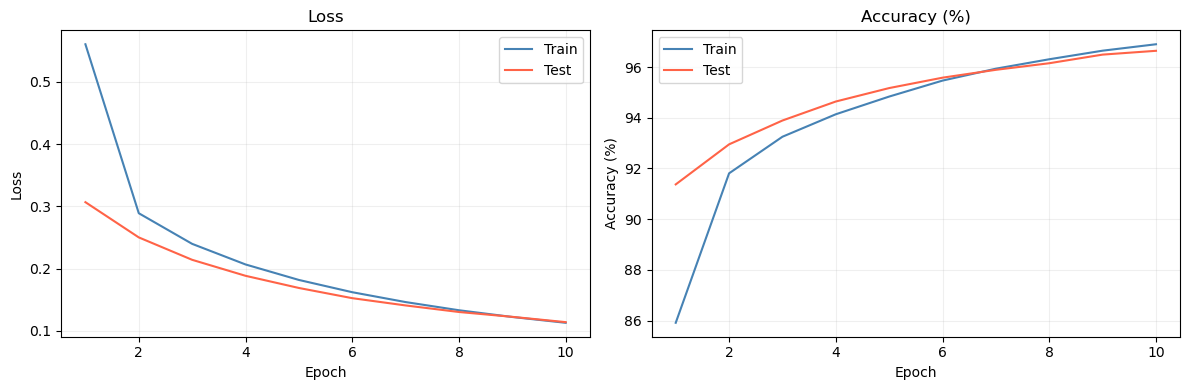

In [40]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

model = SimpleNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epochs = 10

for epoch in range(epochs):

    # Training
    model.train()
    total_loss = 0
    correct = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(correct / len(train_loader.dataset) * 100)

    # Test
    model.eval()
    test_loss = 0
    test_correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            test_correct += (outputs.argmax(1) == labels).sum().item()

    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_correct / len(test_loader.dataset) * 100)

    print(f"Epoch {epoch+1}/{epochs} — "
          f"Train Loss: {train_losses[-1]:.3f}, Train Acc: {train_accuracies[-1]:.2f}% | "
          f"Test Loss: {test_losses[-1]:.3f}, Test Acc: {test_accuracies[-1]:.2f}%")

# Plot
epochs_range = range(1, epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, label='Train', color='steelblue')
ax1.plot(epochs_range, test_losses, label='Test',  color='tomato')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.2)

ax2.plot(epochs_range, train_accuracies, label='Train', color='steelblue')
ax2.plot(epochs_range, test_accuracies, label='Test',  color='tomato')
ax2.set_title('Accuracy (%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [41]:
# # Forward pass -> Loss -> Backward -> Update weights

# # Dataloader - The thing that feeds batches of images and labels into training loop automatically.
 


# from torchvision import datasets, transforms
# # Separate PyTorch library designed to handle image tasks. 
# # datasets has MNIST built in
# # transforms lets you define how to pre-process each image before it enters the model
# from torch.utils.data import Dataloader # batch image feeder


# # 1. Define what transformations to apply to every image

# transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
# # Compose chains multiple transformations together. Applied one after another
# # ToTensor() converts each image from a 28x28 grid of intergers (0-255) into PyTorch tensor with values btwn 0 & 1 - Replaces /255
# # Normalize shifts pixel values so they are centered around zero, the two numbers are the mean and std of the entire MNIST dataset, pre calculated



# # 2. Download and load MNSIT dataset

# # Download MNIST into a folder called ./data (creates it if it does not exist), train true gives 60000 training images, 
# # transform tells it to apply transformations to every image automatically as it loads them
# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# # train false gives 10 000 test images
# test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# # 3. Wrap them in Dataloaders

# # Wraps the dataset in a loader. Everytime the training loop asks for the next batch it automatically grabs 64 images and their labels
# # shuffle true randomises the order every epoch
# train_loader = Dataloader(train_dataset, batch_size=64, shuffle=True)
# # shuffle false - doesnt matter for evaluation
# test_loader = Dataloader(test_dataset, batch_size=64, shuttle=False)



In [42]:
# class SimpleNet(nn.Module):

#     def __init__(self):
#         super().__init__()
#         # Define layers here. Linear: Fully connected layer
#         # Like np.dot(layer_0, weights_1)  plus bias in one line
#         # 784 is the number of inputs (one per pixel),
#         # 400 is the number of outputs (hidden neurons)
#         self.fc1 = nn.Linear(784, 400)

#         # Output layer. 400 inputs (from the hidden layer), 10 outputs (one per digit). 
#         # Replaces weights_2
#         self.fc2 = nn.Linear(400, 10)


#     # This method defines what happens when the data data flows through the network
#     # X is the input (A batch of images). You never call forward directly. This is called automatically when you do model(x)
#     def forward(self, x):
#         x = F.relu(self.fc1(x)) # Passes the input through first fully connected layer (performs matrix multiplication and adds bias). The result x is now, hidden layer's activations.

#         x = self.fc2(x) # Pass the hidden layer through the output layer to produce raw scores. 1 per digit.

#         return x



# # To create and use it

# model = SimpleNet() # runs __init__, sets up the layers
# print(model) # Prints summary of the architecture


In [43]:
# # Training loop for the SimpleNet model. 

# # 1. Create the model
# model = SimpleNet()

# # 2. Define the loss function
# criterion = nn.CrossEntropyLoss()  # Combines softmax and cross-entropy into one

# # 3. Define the optimizer
# optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# # 4. Training loop
# epochs = 20


# for epoch in range(epochs):
#     model.train()
#     total_loss = 0
#     correct = 0


#     for images, labels in train_loader:
#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()
#         correct += (outputs.argmax(1) == labels).sum().item()

#     print(f"Epoch {epoch+1}: Loss = {total_loss:.3f}, Accuracy={correct/len(train_loader.dataset):.2f%}")

In [44]:
# # Test evaluation 

# model.eval()
# test_correct = 0 # A counter. Starts at zero Add to it everytime the model guess correctly


# with torch.no_grad(): # We not updating any weights, "don't track anything.
#     for images, labels in test_loader:
#         outputs = model(images) # Run images through model, get back 64rows of 10numbers(one row per, one number per digit)
#         test_correct += (outputs.argmax(1) == labels).sum().item() # for each image find which digit (0-9) got the highest score, 
#                                                                 # compare each guess to the real answer. True or False for each of the 64 images. 
#                                                                 # Sum. Count how many were true (correct guesses)

# # dovodes correct guesses by 10000 to get the accuracy as a decimal
# test_accuracy = test_correct / len(test_loader.dataset)
# print(f"Test Accuracy: {test_accuracy:.2%}")



## Convolutional Neural Network

In [ ]:
# 28 x 28 images

# INPUT - CONVOLUTIONAL LAYER - RELU - POOL - FC

class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)




    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(x.size(0), -1)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x




Epoch 1/80 — Train Loss: 0.549, Train Acc: 85.03% | Test Loss: 0.278, Test Acc: 91.78%
Epoch 2/80 — Train Loss: 0.157, Train Acc: 95.27% | Test Loss: 0.119, Test Acc: 96.53%
Epoch 3/80 — Train Loss: 0.101, Train Acc: 96.97% | Test Loss: 0.092, Test Acc: 97.34%
Epoch 4/80 — Train Loss: 0.077, Train Acc: 97.71% | Test Loss: 0.066, Test Acc: 97.74%
Epoch 5/80 — Train Loss: 0.063, Train Acc: 98.15% | Test Loss: 0.053, Test Acc: 98.29%
Epoch 6/80 — Train Loss: 0.055, Train Acc: 98.31% | Test Loss: 0.051, Test Acc: 98.41%
Epoch 7/80 — Train Loss: 0.049, Train Acc: 98.58% | Test Loss: 0.053, Test Acc: 98.18%
Epoch 8/80 — Train Loss: 0.044, Train Acc: 98.71% | Test Loss: 0.047, Test Acc: 98.54%
Epoch 9/80 — Train Loss: 0.040, Train Acc: 98.80% | Test Loss: 0.039, Test Acc: 98.72%
Epoch 10/80 — Train Loss: 0.037, Train Acc: 98.87% | Test Loss: 0.035, Test Acc: 98.84%
Epoch 11/80 — Train Loss: 0.034, Train Acc: 98.98% | Test Loss: 0.046, Test Acc: 98.56%
Epoch 12/80 — Train Loss: 0.031, Train Ac

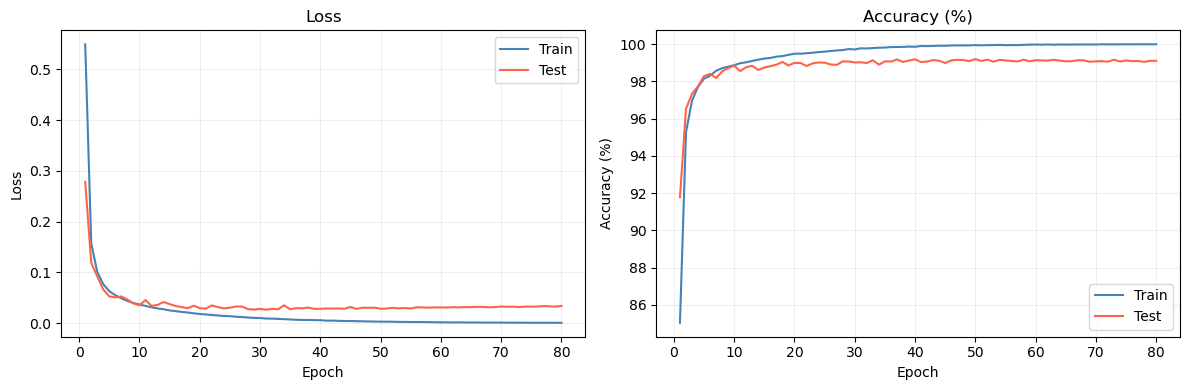

In [55]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

model     = ConvNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
epochs    = 80

for epoch in range(epochs):
    # Training
    model.train()
    total_loss = 0
    correct    = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()

    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(correct / len(train_loader.dataset) * 100)

    # Test
    model.eval()
    test_loss    = 0
    test_correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs   = model(images)
            loss      = criterion(outputs, labels)
            test_loss += loss.item()
            test_correct += (outputs.argmax(1) == labels).sum().item()

    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_correct / len(test_loader.dataset) * 100)

    print(f"Epoch {epoch+1}/{epochs} — "
          f"Train Loss: {train_losses[-1]:.3f}, Train Acc: {train_accuracies[-1]:.2f}% | "
          f"Test Loss: {test_losses[-1]:.3f}, Test Acc: {test_accuracies[-1]:.2f}%")

# Plot
epochs_range = range(1, epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, train_losses, label='Train', color='steelblue')
ax1.plot(epochs_range, test_losses, label='Test',  color='tomato')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.2)

ax2.plot(epochs_range, train_accuracies, label='Train', color='steelblue')
ax2.plot(epochs_range, test_accuracies, label='Test',  color='tomato')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# class ConvNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         # Create first convolutional layer. Takes 1 input channel - MNIST images are greyscale (only one colour channel)
#         # Applies 32 different filters, each 3x3 pixel size
#         # Padding of 1 adds border of zeros around the image so the output stays the same size as input
#         self.conv1 = nn.Conv2d(1,32, kernel_size=3, padding=1)

#         # Second conv layer. It takes the 32 feature maps from conv1 as input and produces 64 feature maps
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

#         # A max pooling layer. Cuts the image in half. Looks at each 2x2 block and keeps only the largest
#         self.pool = nn.MaxPool2d(2, 2)
#         # A fully connected layer. After two rounds of conv + pooling. We have 64 feature maps, each 7 x 7. This layer connects all 3136 values to 128 neurons
#         self.fc1 = nn.Linear(64 * 7 * 7, 128)
#         # Final output layer: 128 -> 10. One score per digit class
#         self.fc2 = nn.Linear(128, 10)

#         # Pass the image through conv1 -> apply ReLU -> apply max pooling. After this, x is 32 feature maps of size 14x14
#         x = self.pool(F.relu(self.conv1(x)))

#         # FLatten - turn 64x7x7 block into a flat list of 3136 numbers. x.size(0) is the batch size, -1 means figure out the rest automatically
#         x = x.view(x.size(0), -1)

#         # Fully connected layer 1 with ReLU. 
#         x = F.relu(self.fc1(x))

#         # Final layer 128 -> 10 raw scores. One per digit
#         x = self.fc2(x)


#     # Method that runs when you pass data through model
#     # x is input - a batch of images with shape 64, 1, 28, 28: 64 images, i colour channel, 28x28 pixels
#     def forward(self, x):
#         # Slide 32 filters across every image (64, 32, 28, 28)
#         # Set any negative values to zero

#         # Max pooling cuts each feature (64, 32, 14, 14)
#         x = self.pool(F.relu(self.conv1(x)))
        
#         # 64 filters scan the 32 feature maps
#         # (64, 64, 14, 14)
#         # halve again. -> (64, 64, 7, 7)
#         x = self.pool(F.relu(self.conv2(x)))

#         # Flatten: x.size(0) is a batch size (64). -1 meaning calculate the rest automatically 
#         x = x.view(x.size(0),-1)

#         # Fully connected layer: 3136 -> 128 neurons, then ReLU 
#         x = F.relu(self.fc1(x))
#         x = self.fc2(x)
#         return(x)
